# Visualize

In [26]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

conn = sqlite3.connect("../data/processed/cleaned_database.sqlite")

# Tabellen anzeigen
tables = pd.read_sql_query("""
SELECT name
FROM sqlite_master
WHERE type='table';
""", conn)

print(tables)

# Datentabelle laden
df = pd.read_sql_query("""
SELECT *
FROM Tweets;
""", conn)

# conn.close()

df.head()

     name
0  Tweets


,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,567588278875213824,neutral,1.0,,,Delta,,JetBlueNews,,0,@JetBlue's new CEO seeks the right balance to ...,,2015-02-16 23:36:05 -0800,Usa,Sydney
1,567590027375702016,negative,1.0,Can't Tell,0.6503,Delta,,nesi_1992,,0,@JetBlue is REALLY getting on my nerves !! 😡😡 ...,,2015-02-16 23:43:02 -0800,Undecided,Pacific Time (US & Canada)
2,567591480085463040,negative,1.0,Late Flight,0.346,United,,CPoutloud,,0,@united yes. We waited in line for almost an h...,,2015-02-16 23:48:48 -0800,"Washington, Dc",
3,567592368451248130,negative,1.0,Late Flight,1,United,,brenduch,,0,@united the we got into the gate at IAH on tim...,,2015-02-16 23:52:20 -0800,,Buenos Aires
4,567594449874587648,negative,1.0,Customer Service Issue,0.3451,Southwest,,VahidESQ,,0,@SouthwestAir its cool that my bags take a bit...,,2015-02-17 00:00:36 -0800,"Los Angeles, Ca",Pacific Time (US & Canada)


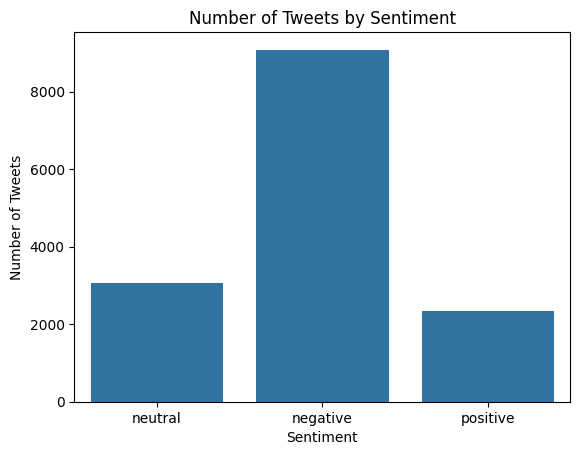

In [27]:
sns.countplot(x='airline_sentiment', data=df)
plt.title("Number of Tweets by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Number of Tweets")
plt.show()

#### Der Datensatz zeigt eine deutliche Dominanz negativer Tweets. Dies spricht dafür, dass Kunden soziale Medien häufig nutzen, um Probleme oder Beschwerden über Fluggesellschaften zu äußern.

In [28]:
query = """
SELECT airline, airline_sentiment, COUNT(*) AS tweet_count
FROM Tweets
WHERE airline_sentiment =='positive'
GROUP BY airline, airline_sentiment
ORDER BY airline, tweet_count DESC;
"""

sentiment_counts_df = pd.read_sql(query, conn)
sentiment_counts_df

,airline,airline_sentiment,tweet_count
0,American,positive,307
1,Delta,positive,544
2,Southwest,positive,570
3,US Airways,positive,269
4,United,positive,492
5,Virgin America,positive,152


C:\Users\SchadlMelani_3k1p0ca\AppData\Local\Temp\ipykernel_13416\2487205880.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='airline', y='tweet_count', data=sentiment_counts_df, palette='deep')


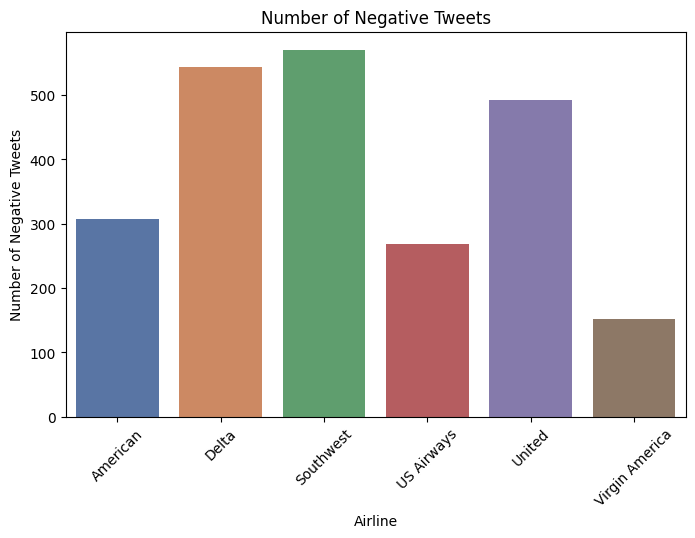

In [29]:
plt.figure(figsize=(8,5))
sns.barplot(x='airline', y='tweet_count', data=sentiment_counts_df, palette='deep')
plt.title('Number of Negative Tweets')
plt.xlabel('Airline')
plt.ylabel('Number of Negative Tweets')
plt.xticks(rotation=45)
plt.show()

In [30]:
query = """
SELECT negativereason, COUNT(*) AS reason_count 
FROM Tweets
WHERE negativereason IS NOT NULL AND negativereason != ''
GROUP BY negativereason
ORDER BY reason_count DESC
LIMIT 5""" # DESCENDING ORDER

neg_reason = pd.read_sql(query, conn)
neg_reason


# FROM table
# WHERE filters the rows
# GROUP groups all rows with the same negativereason together
# COUNT(*) now counts the number of tweets pers reason, not total tweets
# ORDER BY sorts the result

,negativereason,reason_count
0,Customer Service Issue,2885
1,Late Flight,1650
2,Can't Tell,1176
3,Cancelled Flight,829
4,Lost Luggage,719


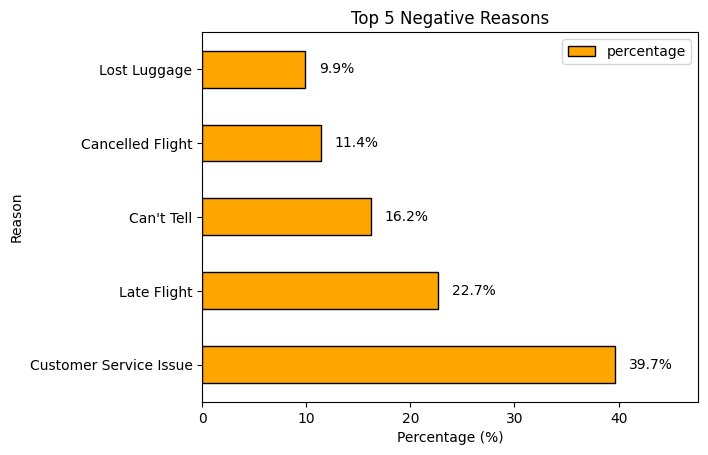

In [31]:
# Prozent berechnen
neg_reason["percentage"] = (
    neg_reason["reason_count"] / neg_reason["reason_count"].sum() * 100
).round(1)

ax = neg_reason.plot(
    kind="barh",
    x="negativereason",
    y="percentage",
    edgecolor="black",
    color = "orange",
)

plt.xlabel("Percentage (%)")
plt.ylabel("Reason")
plt.title("Top 5 Negative Reasons")

# Prozentwerte an die Balken schreiben
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=10)

plt.xlim(0, neg_reason["percentage"].max() * 1.2)

plt.show()

Die Top 5 der negativen Gründe werden von Beschwerden über den Customer Service und Flugverspätungen angeführt. Diese beiden Kategorien machen einen erheblichen Anteil aller negativen Rückmeldungen aus.

In [32]:
query = """
SELECT
    tweet_location,
    COUNT(*) AS tweet_count
FROM Tweets
WHERE tweet_location IS NOT NULL
  AND TRIM(tweet_location) != ''
GROUP BY tweet_location
ORDER BY tweet_count DESC
LIMIT 3;
"""

top_locations = pd.read_sql_query(query, conn)

top_locations

,tweet_location,tweet_count
0,New York,493
1,"Boston, Ma",165
2,"Washington, Dc",158


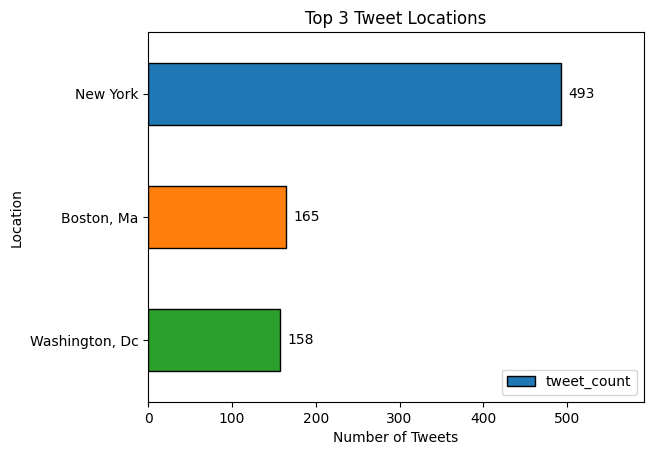

In [33]:
colors = plt.cm.tab10.colors

ax = top_locations.plot(
    kind="barh",
    x="tweet_location",
    y="tweet_count",
    color=colors,
    edgecolor="black"
)

plt.xlabel("Number of Tweets")
plt.ylabel("Location")
plt.title("Top 3 Tweet Locations")

for container in ax.containers:
    ax.bar_label(container, padding=5)

plt.gca().invert_yaxis()  # häufigste Location oben
plt.xlim(0, top_locations["tweet_count"].max() * 1.2)

plt.show()

In [ ]:
query="""
"""